# CNN klasifikator na spektrogramima (sum vs. vozilo) - usporedba s autoencoderom

Ova biljeznica popravlja `scripts/legacy/Classify_Data_2.py` - vec postojeci
**supervised CNN** binarni klasifikator (BG vs. Veh) koji radi nad **spektrogram slikama**,
ne nad feature-vektorima kao `autoencoder_klasifikator.ipynb`. Cilj je direktna usporedba
dva potpuno razlicita pristupa **istom problemu na istim sirovim podacima**
(`data/raw/background`, `data/raw/vehicle`).

**Zasto `Classify_Data_2.py`, a ne `Classify_Data.py`?** `Classify_Data.py` (Metoda 1) ima
hardkodirane, doslovno placeholder Windows putanje (`r" \ Path to audio files\BG_and_Veh"`,
`C:\_DS\_A_MYDS\...`) koje ne postoje nigdje - nije ga moguce pokrenuti bez potpunog pisanja
iznova. `Classify_Data_2.py` (Metoda 2) vec koristi relativnu putanju (`./data/spectrograms/`),
pa je bilo dovoljno popraviti manje stvari.

In [ ]:
import os
import glob

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import librosa

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,roc_curve, roc_auc_score, balanced_accuracy_score,)

RAW_BG_DIR = '../../data/raw/background'
RAW_VEH_DIR = '../../data/raw/vehicle'
SPEC_BG_DIR = '../../data/spectrograms/BG'
SPEC_VEH_DIR = '../../data/spectrograms/Veh'


## 1. Generiranje spektrograma (popravljena verzija `Convert_to_Spectrogram.py`)

Isti parametri kao u legacy skripti: `n_fft=512`, `hop_length=64`, `n_mels=64`, log-power
mel-spektrogram, audio normaliziran na [-1, 1] prije transformacije. Umjesto crtanja preko
matplotlib figure (`specshow` + `savefig` po slici - sporo na ~19000 datoteka), log-mel
niz mapiramo direktno kroz colormap (`magma`) i spremamo preko `PIL` - identican krajnji
"izgled" spektrograma kao slike, samo brze generiranje. Rezolucija generirane slike nije
kriticna jer je `Classify_Data_2.py` svejedno radi `resize` na (223, 163) prije ulaza u mrezu.

Generiranje se preskace ako slike vec postoje (isti "cache" princip kao kod feature ekstrakcije
u ostalim modelima).

In [2]:
FRAME_SIZE = 512
HOP_SIZE = 64
N_MELS = 64


def normalize_audio(audio):
    return 2 * ((audio - np.min(audio)) / np.ptp(audio)) - 1


def audio_to_spectrogram_image(path):
    y, sr = librosa.load(path, sr=None)
    y = y[:sr * 2]
    y = normalize_audio(y)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=FRAME_SIZE, hop_length=HOP_SIZE, n_mels=N_MELS)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    norm = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-9)
    rgb = (cm.magma(norm)[:, :, :3] * 255).astype(np.uint8)
    return Image.fromarray(rgb)


def generate_spectrograms(src_dir, dst_dir, label):
    os.makedirs(dst_dir, exist_ok=True)
    files = [f for f in os.listdir(src_dir) if f.endswith('.wav')]
    existing = len([f for f in os.listdir(dst_dir) if f.endswith('.png')])
    if existing >= len(files):
        print(f"  {label}: vec generirano ({existing} slika), preskacem")
        return
    for i, fname in enumerate(files):
        out_path = os.path.join(dst_dir, fname.replace('.wav', '.png'))
        if os.path.exists(out_path):
            continue
        img = audio_to_spectrogram_image(os.path.join(src_dir, fname))
        img.save(out_path)
        if i % 2000 == 0:
            print(f"  {label}: {i}/{len(files)}")
    print(f"  {label}: gotovo ({len(files)} slika)")


print("Generiram spektrograme (preskace vec generirane)...")
generate_spectrograms(RAW_BG_DIR, SPEC_BG_DIR, 'background')
generate_spectrograms(RAW_VEH_DIR, SPEC_VEH_DIR, 'vehicle')


Generiram spektrograme (preskace vec generirane)...
  background: vec generirano (5792 slika), preskacem
  vehicle: vec generirano (13668 slika), preskacem


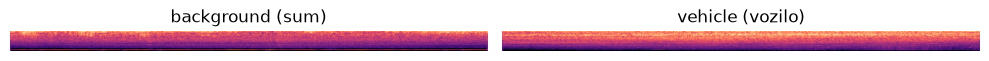

In [ ]:
# primjer spektograma po klasi - actually vidljive razlike
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bg_example = sorted(glob.glob(os.path.join(SPEC_BG_DIR, '*.png')))[0]
veh_example = sorted(glob.glob(os.path.join(SPEC_VEH_DIR, '*.png')))[0]
axes[0].imshow(Image.open(bg_example))
axes[0].set_title('background (sum)')
axes[0].axis('off')
axes[1].imshow(Image.open(veh_example))
axes[1].set_title('vehicle (vozilo)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## 2. Priprema podataka - train/val/test split + `tf.data` pipeline

Stratificirani split na razini datoteka (isti nacin kao kod ostalih modela u ovoj mapi):
70% train, 15% validacija (koristi je LR scheduler/early stopping), 15% test (potpuno
neviđen do finalne evaluacije). `tf.data.Dataset` ucitava i dekodira slike s diska po
batchu (`num_parallel_calls=AUTOTUNE`), umjesto da sve drzi u RAM-u odjednom.

In [ ]:
bg_files = glob.glob(os.path.join(SPEC_BG_DIR, '*.png'))
veh_files = glob.glob(os.path.join(SPEC_VEH_DIR, '*.png'))

paths = bg_files + veh_files
labels = [0] * len(bg_files) + [1] * len(veh_files)  # 0 = background (sum), 1 = vehicle

print(f"background: {len(bg_files)}, vehicle: {len(veh_files)}, ukupno: {len(paths)}")

paths_train, paths_test, y_train, y_test = train_test_split(paths, labels, test_size=0.15, stratify=labels, random_state=42)
paths_train, paths_val, y_train, y_val = train_test_split(paths_train, y_train, test_size=0.15, stratify=y_train, random_state=42)

print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")

IMG_HEIGHT, IMG_WIDTH = 163, 223
BATCH_SIZE = 64


def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(paths_train, y_train, shuffle=True)
val_ds = make_dataset(paths_val, y_val)
test_ds = make_dataset(paths_test, y_test)


background: 5792, vehicle: 13668, ukupno: 19460
Train: 14059, Val: 2482, Test: 2919


## 3. Arhitektura (identicna `Classify_Data_2.py`)

4 konvolucijska bloka (32 -> 64 -> 128 -> 256 filtera), svaki s dropoutom i max poolingom,
zatim Dense(64) -> Dropout -> Dense(16) -> Dense(1, sigmoid). LR step-decay scheduler
(smanjuje learning rate 10x svakih 25 epoha) - preuzeto direktno iz legacy koda. Dodan je
`EarlyStopping` na validacijski gubitak (legacy je trenirao fiksnih 10 epoha bez toga) -
sigurnosna mjera protiv overfittinga na punom datasetu.

In [5]:
tf.keras.utils.set_random_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])
model.summary()


def step_decay(epoch, lr):
    initial_lr = 0.0001
    drop = 0.1
    epochs_drop = 25
    return initial_lr * (drop ** (epoch // epochs_drop))


lr_scheduler = tf.keras.callbacks.LearningRateScheduler(step_decay, verbose=0)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 161, 221, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 161, 221, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 110, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 78, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 78, 108, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 39, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 37, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 12, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 24576)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,572,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,962,401 (7.49 MB)

 Trainable params: 1,962,401 (7.49 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[lr_scheduler, early_stop],
    verbose=2,
)


Epoch 1/15


/Users/dtx/miniconda3/envs/ai/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


220/220 - 194s - 882ms/step - accuracy: 0.7980 - loss: 0.4314 - val_accuracy: 0.8658 - val_loss: 0.4256 - learning_rate: 1.0000e-04
Epoch 2/15
220/220 - 172s - 780ms/step - accuracy: 0.8717 - loss: 0.2941 - val_accuracy: 0.8993 - val_loss: 0.3911 - learning_rate: 1.0000e-04
Epoch 3/15
220/220 - 171s - 777ms/step - accuracy: 0.9032 - loss: 0.2395 - val_accuracy: 0.9158 - val_loss: 0.3485 - learning_rate: 1.0000e-04
Epoch 4/15
220/220 - 171s - 779ms/step - accuracy: 0.9232 - loss: 0.1961 - val_accuracy: 0.8795 - val_loss: 0.3579 - learning_rate: 1.0000e-04
Epoch 5/15
220/220 - 172s - 781ms/step - accuracy: 0.9323 - loss: 0.1771 - val_accuracy: 0.9259 - val_loss: 0.3127 - learning_rate: 1.0000e-04
Epoch 6/15
220/220 - 181s - 823ms/step - accuracy: 0.9365 - loss: 0.1691 - val_accuracy: 0.9416 - val_loss: 0.2626 - learning_rate: 1.0000e-04
Epoch 7/15
220/220 - 174s - 790ms/step - accuracy: 0.9410 - loss: 0.1574 - val_accuracy: 0.9093 - val_loss: 0.3162 - learning_rate: 1.0000e-04
Epoch 8/15

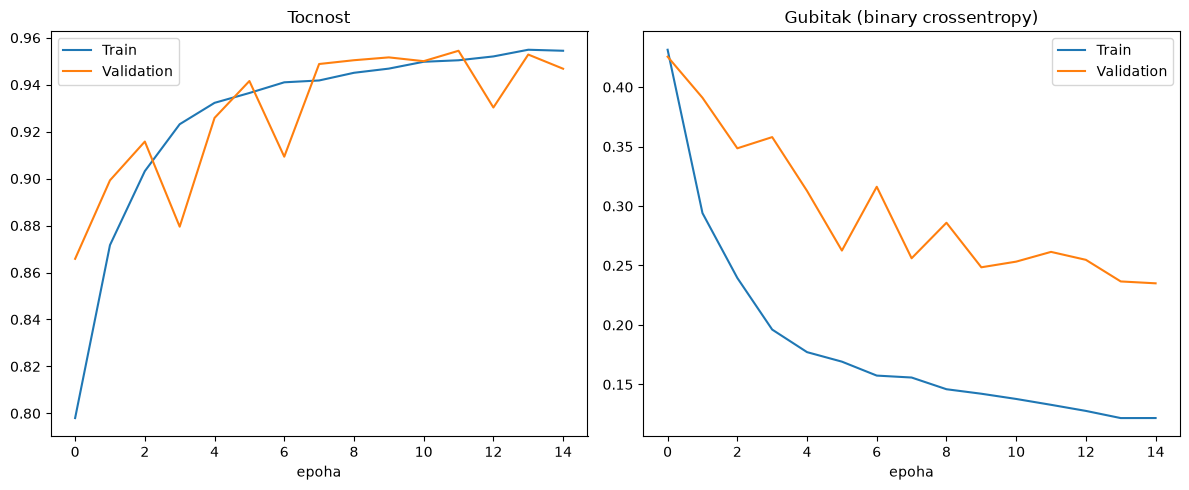

Broj odradjenih epoha: 15


In [ ]:
# prikaz kretanja tocnosti (povecava se) i gubitka (smanjuje se) po epohama 
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(history.history['accuracy'], label='Train')
axs[0].plot(history.history['val_accuracy'], label='Validation')
axs[0].set_title('Tocnost')
axs[0].set_xlabel('epoha')
axs[0].legend()

axs[1].plot(history.history['loss'], label='Train')
axs[1].plot(history.history['val_loss'], label='Validation')
axs[1].set_title('Gubitak (binary crossentropy)')
axs[1].set_xlabel('epoha')
axs[1].legend()

plt.tight_layout()
plt.show()

print(f"Broj odradjenih epoha: {len(history.history['loss'])}")


## 4. Evaluacija na test skupu

Iste metrike kao u `autoencoder_klasifikator.ipynb` (classification report, confusion matrix,
ROC-AUC, balanced accuracy) radi izravne usporedivosti pristupa.

                  precision    recall  f1-score   support

sum (background)       0.88      0.96      0.92       869
vozilo (vehicle)       0.98      0.95      0.96      2050

        accuracy                           0.95      2919
       macro avg       0.93      0.95      0.94      2919
    weighted avg       0.95      0.95      0.95      2919



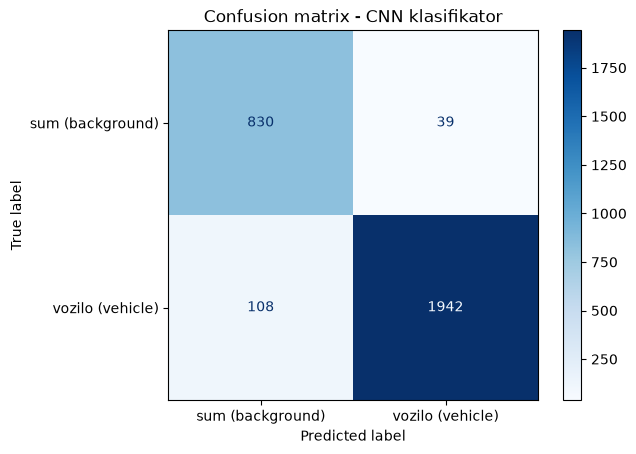

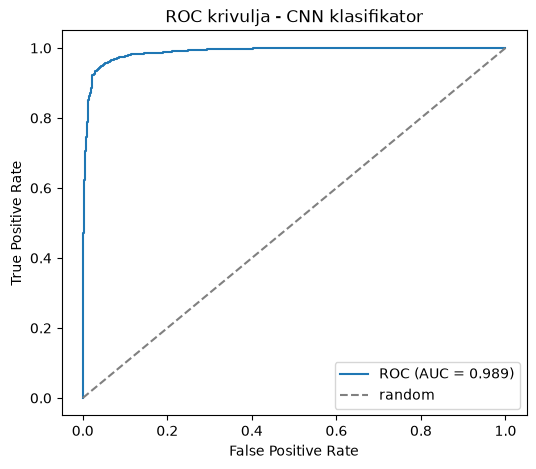

ROC-AUC: 0.989


In [9]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_score = model.predict(test_ds, verbose=0).flatten()
y_pred = (y_score > 0.5).astype(int)

target_names = ['sum (background)', 'vozilo (vehicle)']
print(classification_report(y_true, y_pred, target_names=target_names))

cm_cnn = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=target_names)
disp.plot(cmap='Blues')
plt.title('Confusion matrix - CNN klasifikator')
plt.show()

auc_cnn = roc_auc_score(y_true, y_score)
fpr_cnn, tpr_cnn, _ = roc_curve(y_true, y_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr_cnn, tpr_cnn, label=f'ROC (AUC = {auc_cnn:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC krivulja - CNN klasifikator')
plt.legend()
plt.show()

print(f"ROC-AUC: {auc_cnn:.3f}")


## 5. Izravna usporedba: CNN vs. autoencoder

Oba modela su evaluirana na istim sirovim podacima (`data/raw/background`,
`data/raw/vehicle`), ali fundamentalno drugacijim pristupom:

| | CNN (ova biljeznica) | Autoencoder (`autoencoder_klasifikator.ipynb`) |
|---|---|---|
| Ulaz | 2D spektrogram slika | 1D feature-vektor (25 znacajki) |
| Trening vidi | Obje klase, oznacene | Iskljucivo `background` |
| Pristup | Supervised (diskriminativan) | Unsupervised anomaly detection (rekonstrukcijski) |

Konkretni brojevi:

| Metrika | CNN | Autoencoder (Youden's J threshold) |
|---|---|---|
| ROC-AUC | 0.989 | 0.878 |
| accuracy | 0.951 | 0.805 |

CNN ocekivano ostvaruje bolje rezultate jer (a) vidi obje klase u treningu
(direktan supervised signal), i (b) radi nad puno bogatijom reprezentacijom (2D
vremensko-frekvencijska slika) nego autoencoder (25 agregiranih brojeva po 2s isjecku).
Ako je razlika manja nego sto bi se ocekivalo, to je znak da vecina razlikovne informacije
BG/Veh vec postoji i u jednostavnijem feature-vektoru, sto bi bio koristan uvid za odabir
modela u produkciji (jednostavniji, brzi feature-vektor model vs. skuplji CNN).